In [ ]:
# Taking the already collected data
import pandas as pd

mdf = pd.read_csv('linked_mortality_file_1999_2000.csv')
gdf = pd.read_sas("DEMO.xpt", format="xport")
smq = pd.read_sas("SMQ.xpt", format="xport")

# Merge on SEQN
df = gdf.merge(mdf, on="SEQN", how="inner")
df = df.merge(smq, on="SEQN", how="inner")

df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,SMQ180,SMD190,SMQ200,SMD203,SMQ205,SMQ210,SMD220,SMQ230,SMD233,SMD235
0,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
1,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,2.0,NaN,NaN,NaN,NaN,1.0,5.397605e-79,NaN,NaN,NaN
2,7.0,1.0,2.0,2.0,2.0,59.0,712.0,712.0,4.0,2.0,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
3,10.0,1.0,2.0,2.0,1.0,43.0,518.0,518.0,4.0,2.0,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
4,12.0,1.0,2.0,1.0,1.0,37.0,453.0,454.0,3.0,1.0,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN


In [ ]:
# Select the features and target variable
features = ['SMD090', 'SMQ040', 'SMD030']
target = 'PERMTH_INT'

df_knn = df[features + [target]].dropna()

X = df_knn[features]
y = df_knn[target]

print(X.shape)

(996, 3)


In [ ]:
# Checking if features are numeric
df_knn.describe()

,SMD090,SMQ040,SMD030,PERMTH_INT
count,996.000000,996.000000,9.960000e+02,996.000000
mean,15.724900,1.175703,2.008735e+01,200.145582
std,33.346794,0.380758,4.453281e+01,67.643300
min,1.000000,1.000000,5.397605e-79,1.000000
25%,5.000000,1.000000,1.500000e+01,182.000000
50%,10.000000,1.000000,1.700000e+01,233.000000
75%,20.000000,1.000000,2.000000e+01,242.000000
max,999.000000,2.000000,9.990000e+02,249.000000


In [10]:
# Train-test split and feature scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Because KNN uses distance calculations, standardizing the features ensures no single variable dominates

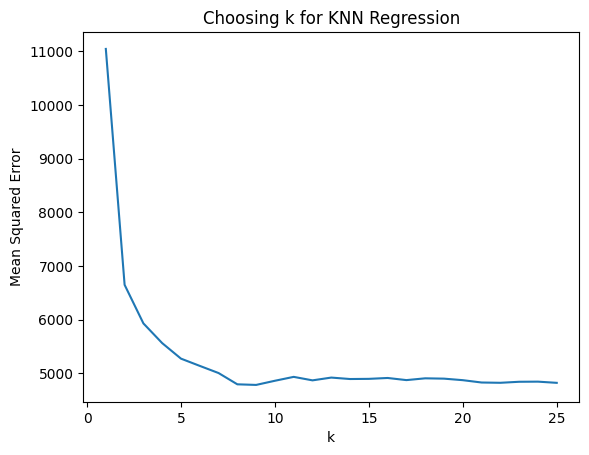

Best k: 9


In [11]:
# Finding Best k

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

k_values = range(1, 26)
mse_values = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)

plt.plot(k_values, mse_values)
plt.xlabel("k")
plt.ylabel("Mean Squared Error")
plt.title("Choosing k for KNN Regression")
plt.show()

best_k = k_values[np.argmin(mse_values)]
print("Best k:", best_k)

In [12]:
# Final Model

from sklearn.metrics import r2_score

knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Final MSE:", mse)
print("Final R^2:", r2)

Final MSE: 4787.049258846359
Final R^2: -0.044141160909574984


# How I found k

To predict life expectancy (measured by PERMTH_INT), I used a K-Nearest Neighbor Regressor with smoking behavior variables: average cigarettes per day (SMD090), current smoking status (SMQ040), and age started smoking regularly (SMD030).

Because KNN is distance-based, I standardized all predictors before modeling. I then evaluated values of k from 1 to 25 using a 70/30 train-test split and selected the value of k that minimized the test-set Mean Squared Error (MSE).

The MSE versus k plot shows that error decreases sharply from very small values of k, stabilizes around k = 9, and then remains relatively flat for larger values. The optimal value selected was: k=9

Using k=9, I found:

Mean Squared Error (MSE) = 4787

R²: -0.044

# Performance Interpretation

The negative R² indicates that the model performs slightly worse than simply predicting the mean life expectancy for all individuals. This suggests that smoking behavior alone provides very limited predictive power for overall life expectancy measured in months.

This result is not surprising. Life expectancy is influenced by many factors beyond smoking behavior (i.e. age, underlying health conditions, socioeconomic status, genetics, and access to healthcare).  While smoking is strongly associated with mortality risk, these three smoking variables alone do not capture enough variation to accurately predict how long individuals live.

Additionally, KNN is a local averaging method, meaning predictions are based on neighboring observations. If smoking behavior does not strongly separate individuals by survival time, the model struggles to generate precise estimates.

Overall, the model demonstrates that smoking behavior contributes some information but is insufficient on its own to explain variation in life expectancy.